In [1]:
import pandas as pd

# specify columns to read
df= pd.read_csv("eval_returns\eval_returns_four_room_gpi-pd_weight_0.0_1.0_1777885103.csv", usecols=["avg_vec_return_0", "avg_vec_return_1", "avg_vec_return_2", "avg_vec_return_3"])

<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
C:\Users\skakr\AppData\Local\Temp\ipykernel_6544\674915596.py:4: SyntaxWarning: invalid escape sequence '\e'
  df= pd.read_csv("eval_returns\eval_returns_four_room_gpi-pd_weight_0.0_1.0_1777885103.csv", usecols=["avg_vec_return_0", "avg_vec_return_1", "avg_vec_return_2", "avg_vec_return_3"])


<Axes: xlabel='avg_vec_return_1', ylabel='avg_vec_return_3'>

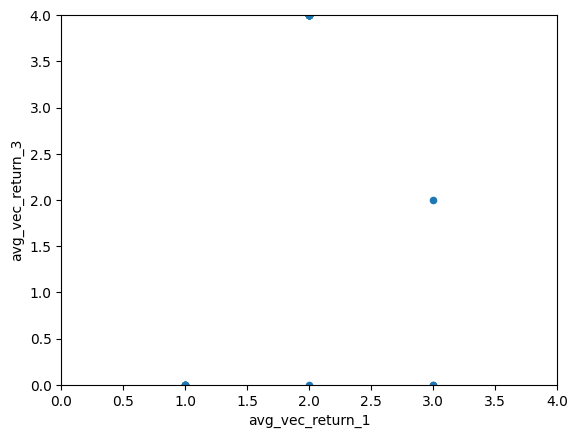

In [8]:
df.plot(kind='scatter', x='avg_vec_return_1', y='avg_vec_return_3', xlim=(0, 4), ylim=(0, 4))

In [ ]:
# pproximate Pareto front from a trained GPIPD/GPILS agent
from morl_baselines.common.evaluation import policy_evaluation_mo
from morl_baselines.common.weights import equally_spaced_weights
from morl_baselines.common.pareto import filter_pareto_dominated
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

N_WEIGHTS = 25
N_EPISODES_PER_WEIGHT = 5

returns = df.values

# Keep only non-dominated points (Pareto front approximation)
pareto_front = np.array(list(filter_pareto_dominated(returns)), dtype=np.float32)

print(f"Collected points: {len(returns)}")
print(f"Non-dominated points: {len(pareto_front)}")
print("Pareto front shape:", pareto_front.shape)

# Sort for cleaner plotting in 2D
if pareto_front.shape[1] == 2:
    pareto_front = pareto_front[np.argsort(pareto_front[:, 0])]

# Plot
if pareto_front.shape[1] == 2:
    plt.figure(figsize=(6, 5))
    plt.scatter(returns[:, 0], returns[:, 1], s=12, alpha=0.25, label="all eval points")
    plt.plot(pareto_front[:, 0], pareto_front[:, 1], "o-", color="black", label="pareto front")
    plt.xlabel("blue_triangle")
    plt.ylabel("red_triangle")
    plt.title("Approximated Pareto Front")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()
elif pareto_front.shape[1] == 3:
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(pareto_front[:, 0], pareto_front[:, 1], pareto_front[:, 2], s=20)
    ax.set_xlabel("objective_1")
    ax.set_ylabel("objective_2")
    ax.set_zlabel("objective_3")
    ax.set_title("Approximated Pareto Front")
    plt.show()
else:
    for i in range()

# Optional: save to CSV
# front_df = pd.DataFrame(pareto_front, columns=[f"objective_{i+1}" for i in range(pareto_front.shape[1])])
# front_df.to_csv("run_code/gpipd_pareto_front.csv", index=False)
# front_df.head()

Collected points: 25
Non-dominated points: 2
Pareto front shape: (2, 4)
Front has 4 objectives; skipping plot.
